In [1]:
# Execute this cell
import numpy as np
from scipy import stats
import scipy
import matplotlib.pyplot as plt
import pandas as pd
#%matplotlib inline
#%config InlineBackend.figure_format='retina'

from scipy import integrate
from scipy.stats import norm

# Tasks

Let's go back to our previous example on the astrophysical transient.


8) Fit the same model from before with the same priors,  but this time use nested sampling.

$y = b$, for $t<t_0$

$y = b + A\exp[-\alpha(t-t_0)]$, for $t\geq t_0$

Be careful with how you transform your parameter space into a unit hypercube for the nested sampling priors (I used `ppf` from `scipy.stats.uniform`, but there are other ways to do it)

An appropriate check on whether you have done things correctly is that the posterior samples you get from the burst analysis here should give an equivalent corner plot to the MCMC you did earlier.

7) Another possible model that may explain the data is a Gaussian profile described by:

$y = b + A\exp[-(t-t_0)^2 / 2\sigma_W^2]$

Fit this model usign nested sampling and reasonable priors (this time is up to you to decide...)

9) Unlike MCMCs, nested sampling provides the Bayesian evidence. Compute the Bayesian evidence for this Gaussian model, and for the original burst model. Which model is the favored description of the data? Express this in terms of the Jeffrey's scale.

### Data and model inspection

In [2]:
data = np.load("../solutions/transient.npy")

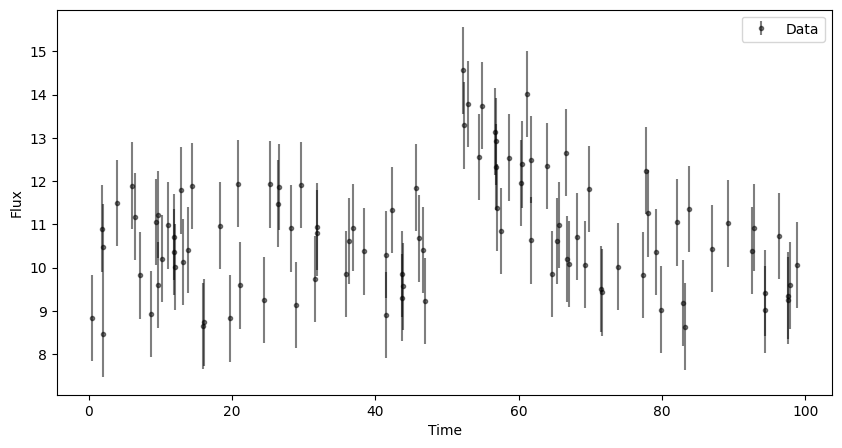

In [3]:
t, y, y_err = data[:, 0], data[:, 1], data[:, 2]


plt.figure(figsize=(10, 5))
plt.errorbar(t, y, yerr=y_err, fmt='.k', capsize=0, alpha=0.5, label='Data')
plt.xlabel('Time')
plt.ylabel('Flux')
plt.legend()
plt.show()

In [4]:
def burst_model(theta, t):
    b, A, t0, alpha = theta
    model = np.full_like(t, b)  # Costant background b
    mask = t >= t0
    model[mask] += A * np.exp(-(t[mask] - t0) *alpha)
    return model

def gaussian_model(theta, t):
    b, A, t0, sigma = theta
    model = b + A * np.exp(-(t-t0)**2/(2*sigma**2))
    return model
    

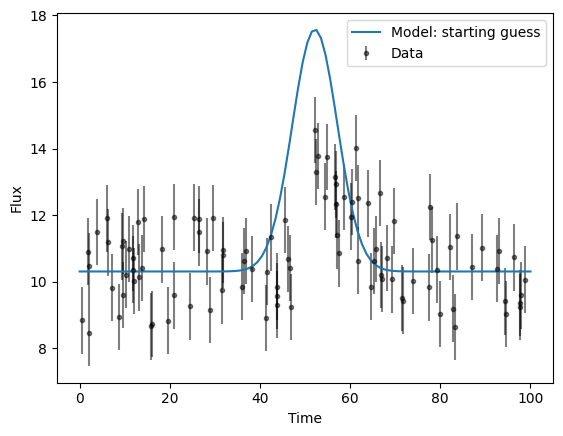

In [5]:
t_ax = np.linspace(0,100,100)
initial_guess = [np.mean(y[:10]), np.max(y)/2, t[np.argmax(y)], 5] #possible parameters
y_ax = gaussian_model(initial_guess, t_ax)
plt.errorbar(t, y, yerr=y_err, fmt='.k', capsize=0, alpha=0.5, label='Data')
plt.plot(t_ax,y_ax,label='Model: starting guess')
plt.xlabel('Time')
plt.ylabel('Flux')
plt.legend()
plt.show()

### Nested sampling through dynesty

In [6]:
import dynesty

In [9]:
ndim = 4

def log_likelihood(theta, data, model):
    x, y, sigma_y = data.T
    if model =='burst_model':
        y_fit = burst_model(theta, x)
    elif model == 'gaussian_model':
        y_fit = gaussian_model(theta, x)

    return -0.5 * np.sum((y-y_fit)**2 / sigma_y**2 ) 


def ptform(u,model):
    """Transforms the uniform random variables `u ~ Unif[0., 1.)`
    to the parameters of interest."""

    x = np.array(u)  #ausiliar vector

    x[0] = scipy.stats.uniform(loc=0,scale=50).ppf(u[0]) #b
    x[1] = scipy.stats.uniform(loc=0,scale=50).ppf(u[1]) #A
    x[2] = scipy.stats.uniform(loc=0,scale=100).ppf(u[2]) #t0
   
    if model =='burst_model':
        x[3] = scipy.stats.loguniform.ppf(u[3],np.exp(-5),np.exp(5)) #alpha
    elif model =='gaussian_model':
        x[3] = scipy.stats.loguniform.ppf(u[3],np.exp(-3),np.exp(3)) #sigma

    return x

### Burst model

In [25]:
# "Static" nested sampling.
sampler = dynesty.NestedSampler(log_likelihood, ptform, ndim, logl_args=[data, 'burst_model'], ptform_args=['burst_model'])#, nlive=400)
#sampler.run_nested()
#sresults = sampler.results

In [26]:
sampler.run_nested()
sresults = sampler.results

iter: 2813 | bound: 20 | nc: 95 | ncall: 27832 | eff(%): 10.107 | loglstar:   -inf < -88.631 <    inf | logz: -95.643 +/-  0.111 | dlogz: 38.683 >  0.509                                             C:\Users\annat\anaconda3\envs\astro_env\Lib\site-packages\dynesty\bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
iter: 3854 | bound: 110 | nc: 1 | ncall: 83267 | eff(%):  4.628 | loglstar:   -inf < -86.620 <    inf | logz: -93.175 +/-  0.106 | dlogz: 35.980 >  0.509                                             C:\Users\annat\anaconda3\envs\astro_env\Lib\site-packages\dynesty\bounding.py:707: UserWarning: The enlargement factor for 

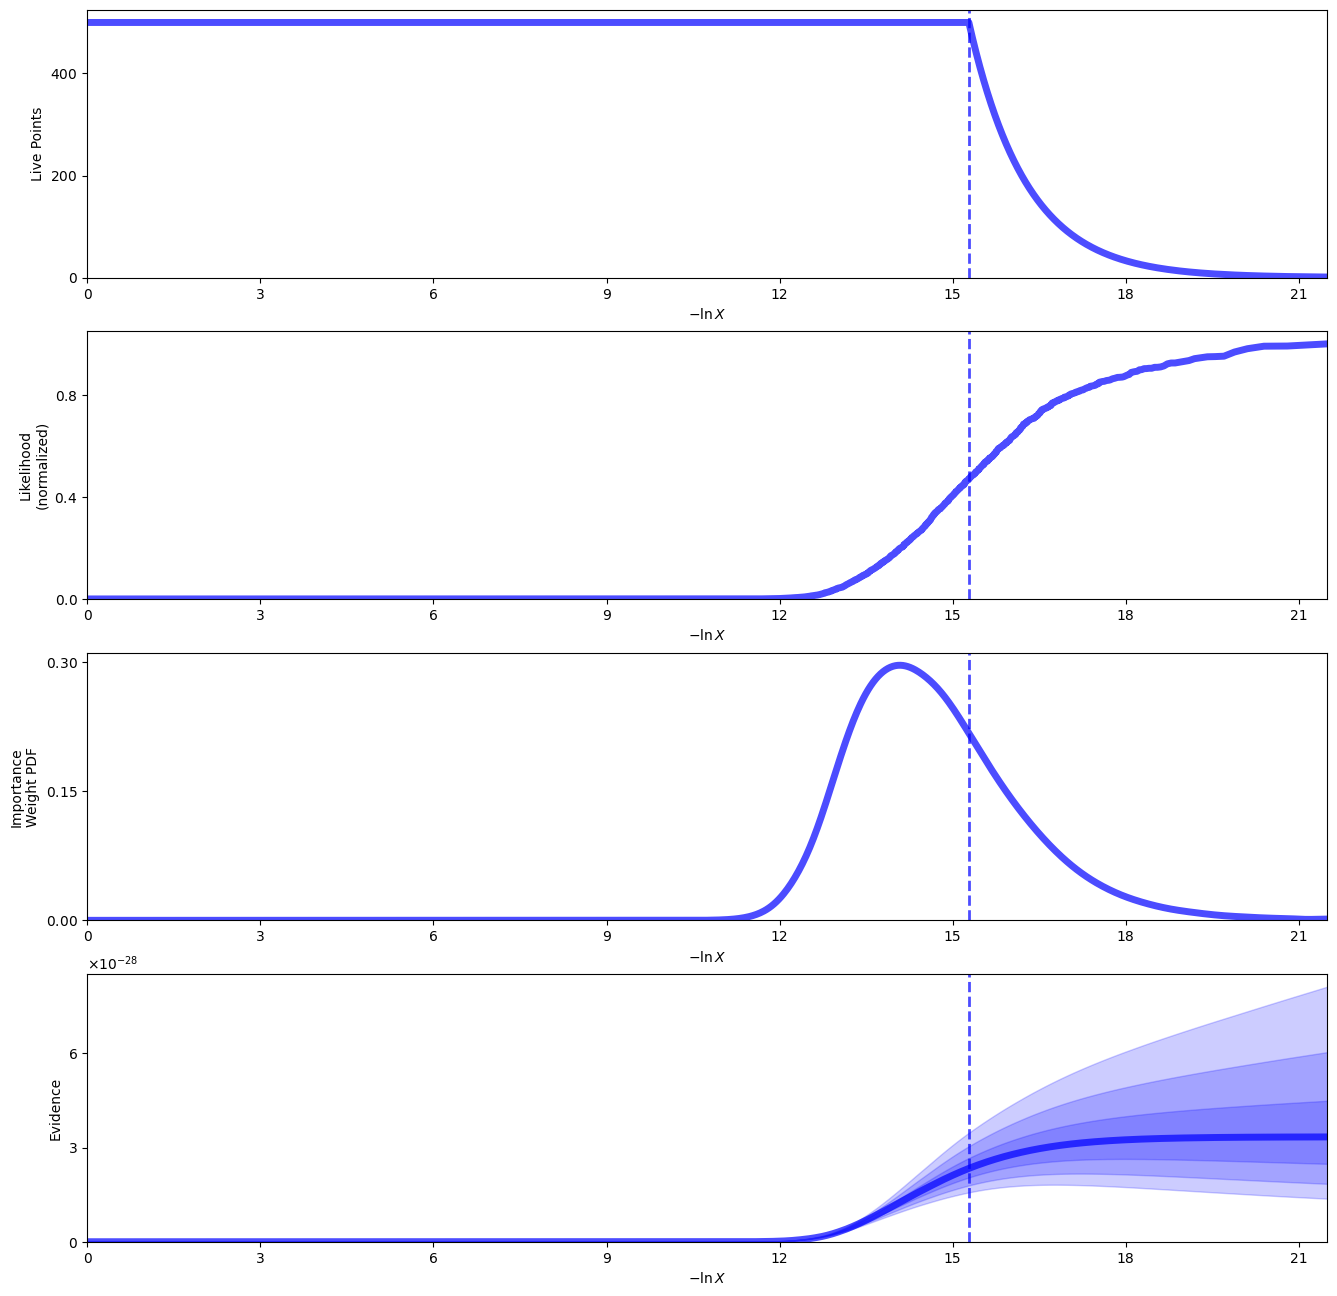

In [12]:
from dynesty import plotting as dyplot

# Plot a summary of the run.
rfig, raxes = dyplot.runplot(sresults)

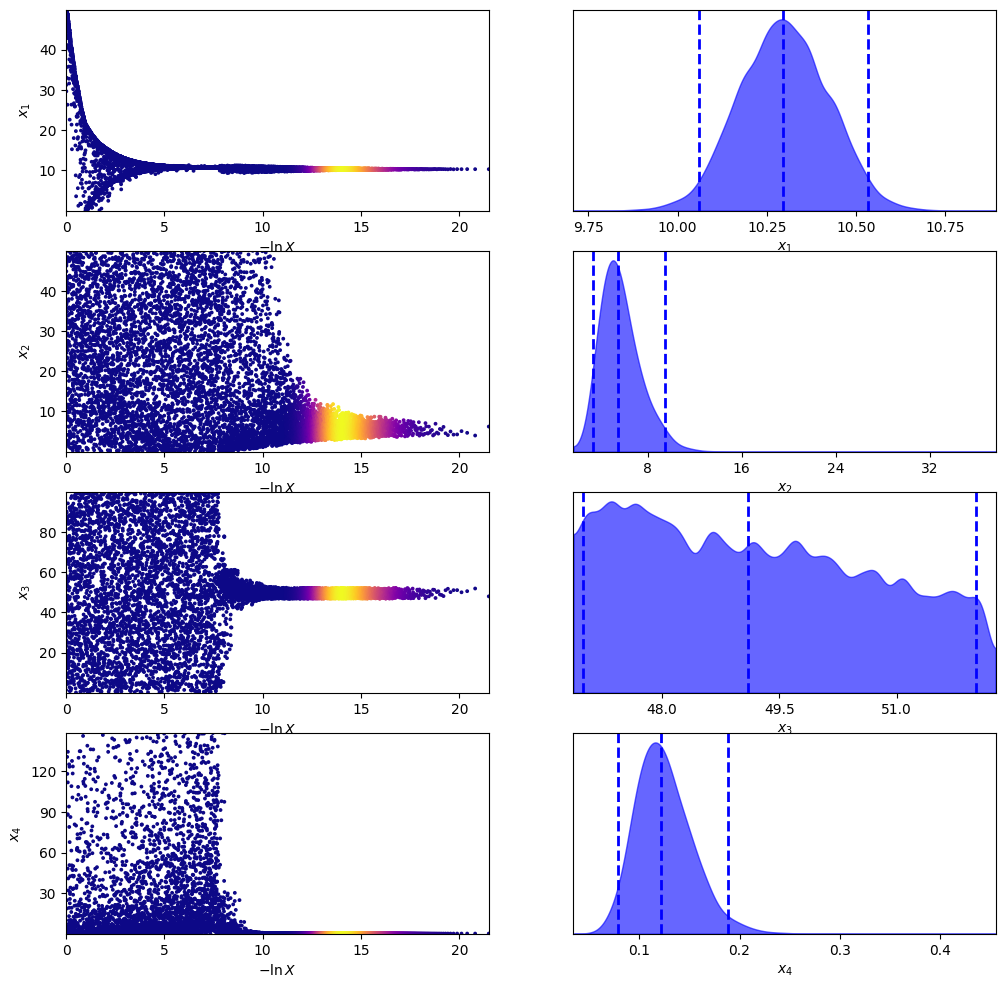

In [13]:
tfig, taxes = dyplot.traceplot(sresults)

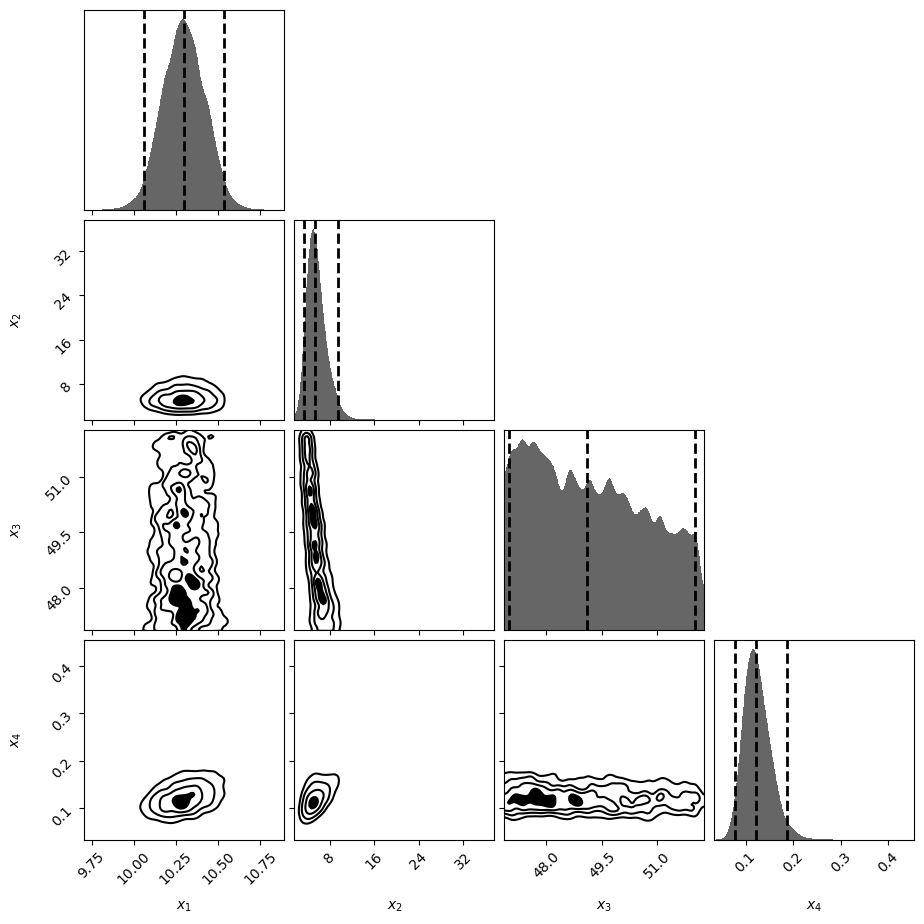

In [14]:
cfig, caxes = dyplot.cornerplot(sresults)

In [15]:
from dynesty import utils as dyfunc


# Extract sampling results.
samples = sresults.samples  # samples
weights = np.exp(sresults.logwt - sresults.logz[-1])  # normalized weights


evidence = sresults.logz[-1] #evidence
print("Bayesian evidence", np.exp(evidence))

# Compute 10%-90% quantiles.
quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights)
             for samps in samples.T]
print('68% parameter credible regions are:\n ' + str(quantiles) + '\n')

# Compute weighted mean and covariance.
mean, cov = dyfunc.mean_and_cov(samples, weights)
print('Mean and covariance of parameters are: ' + str(mean) + '\n' + str(cov))

# Generate a new set of results with statistical+sampling uncertainties.
#results_sim = dyfunc.simulate_run(sresults)

Bayesian evidence 3.340490328865057e-28
68% parameter credible regions are:
 [[10.17471557910202, 10.4238472368688], [4.117130189475598, 7.284953085479033], [47.52493565320592, 51.02478796968403], [0.09776637361976723, 0.1515504213219608]]

Mean and covariance of parameters are: [10.29689735  5.68558869 49.21481521  0.12487975]
[[ 1.51464029e-02  1.42104339e-02 -3.13110066e-03  1.36885728e-03]
 [ 1.42104339e-02  2.68609736e+00 -1.69143697e+00  2.58715915e-02]
 [-3.13110066e-03 -1.69143697e+00  2.26413925e+00 -1.71242865e-03]
 [ 1.36885728e-03  2.58715915e-02 -1.71242865e-03  7.76369151e-04]]


In [21]:
quantiles = [dyfunc.quantile(samps, [0.05, 0.5, 0.95], weights=weights)
             for samps in samples.T]
for q,l in zip(quantiles,['b', 'A', 't0', 'alpha']):
    low,med,up=q
    print(l+"   "+str(med)+" +"+str(up-med)+" -"+str(med-low))

b   10.296416351725089 +0.2015402774235664 -0.19800846472620748
A   5.438822513882844 +3.444503753795562 -1.8974431263863187
t0   49.09880539069693 +2.6991934486108704 -2.024989103920902
alpha   0.12181385671506854 +0.05164363473849608 -0.03628213489649432


In [22]:

sresults.summary()

Summary
nlive: 500
niter: 7647
ncall: 119187
eff(%):  6.835
logz: -63.266 +/-  0.297


In [16]:
# Resample weighted samples.
samples_equal = dyfunc.resample_equal(samples, weights)

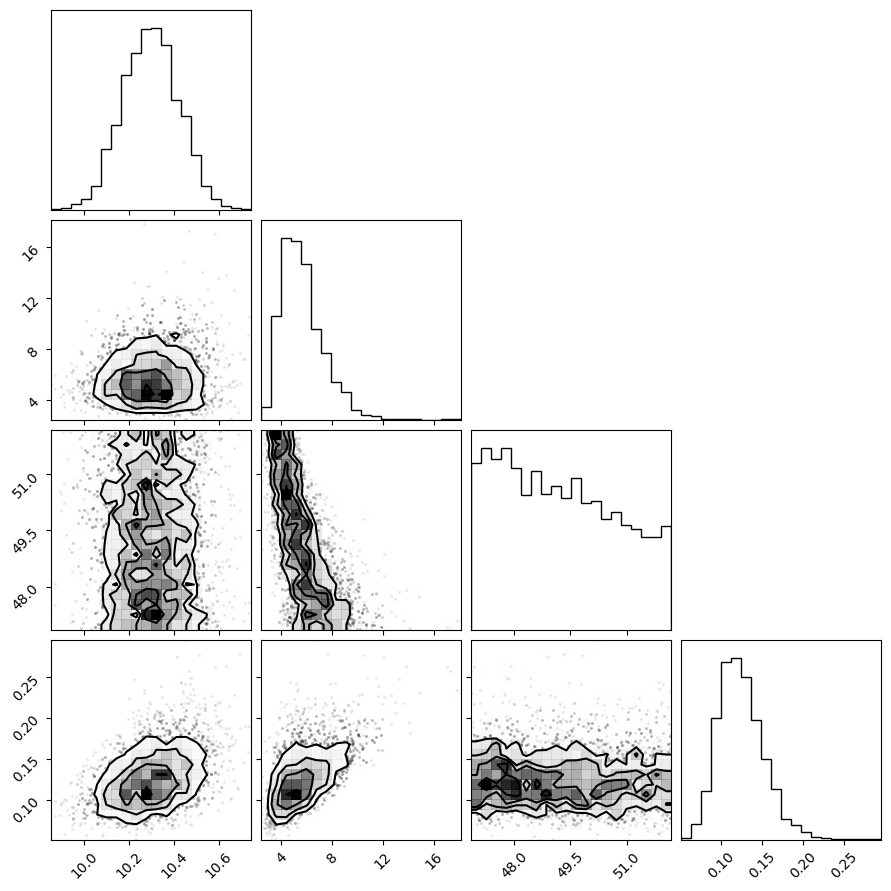

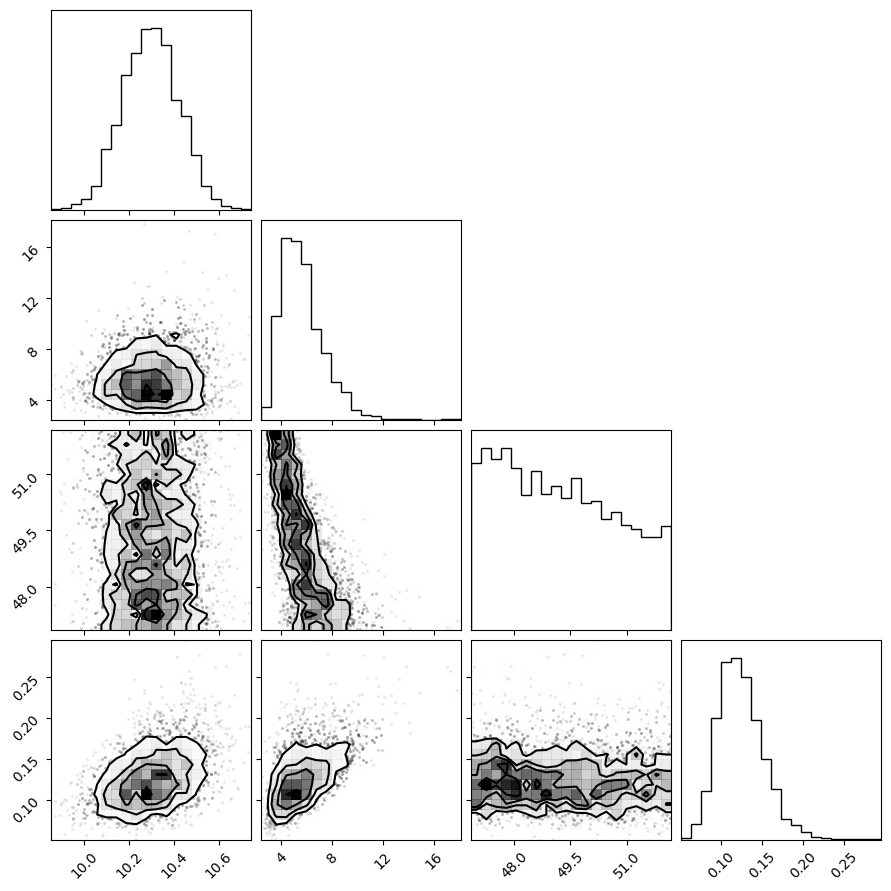

In [19]:
import corner
corner.corner(samples_equal)

In [18]:
samples_equal

array([[10.3559118 ,  6.46622301, 48.31305932,  0.11983968],
       [10.43161226,  9.19101732, 47.58834625,  0.16461262],
       [10.32482511,  4.48733794, 49.72262316,  0.10051933],
       ...,
       [10.33911864,  4.90846615, 50.48231028,  0.12305101],
       [10.18447628,  5.31278285, 49.80213791,  0.12179511],
       [10.1875656 ,  7.45561905, 48.3010457 ,  0.1364115 ]],
      shape=(8147, 4))

### Gaussian model

In [27]:
# "Static" nested sampling.
sampler2 = dynesty.NestedSampler(log_likelihood, ptform, ndim, logl_args=[data, 'gaussian_model'], ptform_args=['gaussian_model'])#, nlive=400) #sample='rslice', nlive=1000)
#sampler.run_nested()
#sresults = sampler.results

In [28]:
sampler2.run_nested()
sresults2 = sampler2.results

iter: 4190 | bound: 83 | nc: 100 | ncall: 64240 | eff(%):  6.522 | loglstar:   -inf < -86.646 <    inf | logz: -94.135 +/-  0.114 | dlogz: 29.390 >  0.509                                            C:\Users\annat\anaconda3\envs\astro_env\Lib\site-packages\dynesty\bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
iter: 4195 | bound: 86 | nc: 150 | ncall: 72494 | eff(%):  5.787 | loglstar:   -inf < -86.628 <    inf | logz: -94.131 +/-  0.114 | dlogz: 29.376 >  0.509                                            C:\Users\annat\anaconda3\envs\astro_env\Lib\site-packages\dynesty\bounding.py:707: UserWarning: The enlargement factor for 

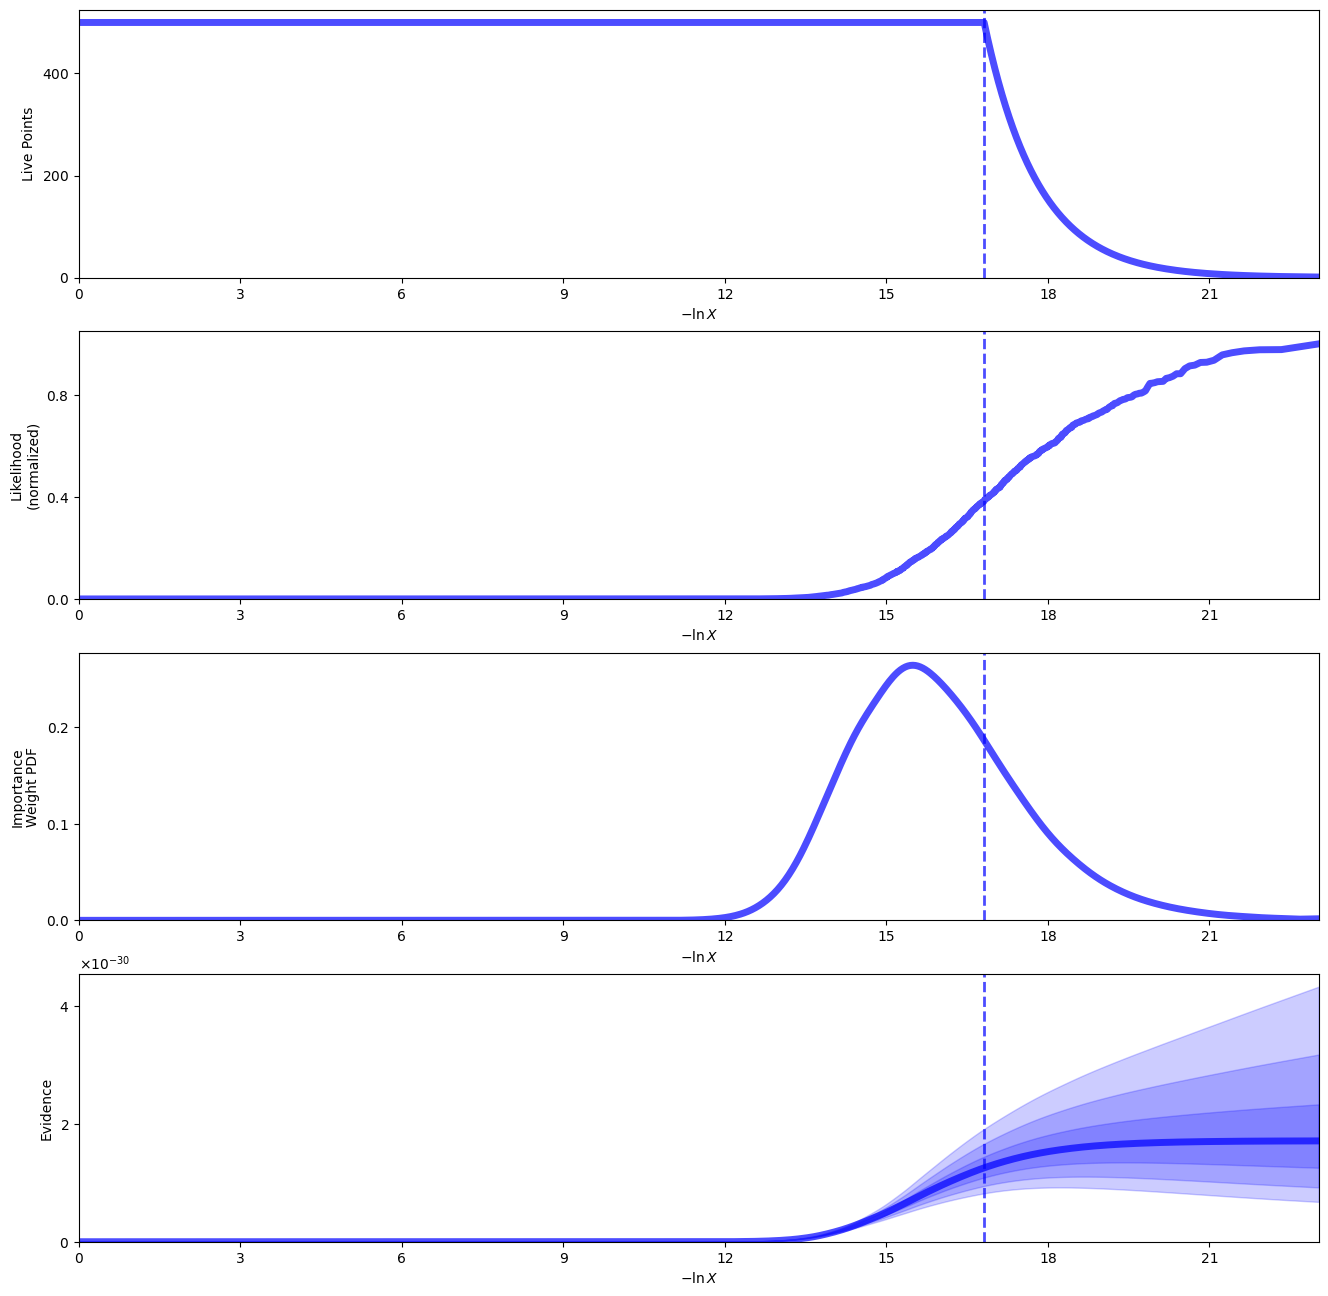

In [29]:

# Plot a summary of the run.
rfig, raxes = dyplot.runplot(sresults2)

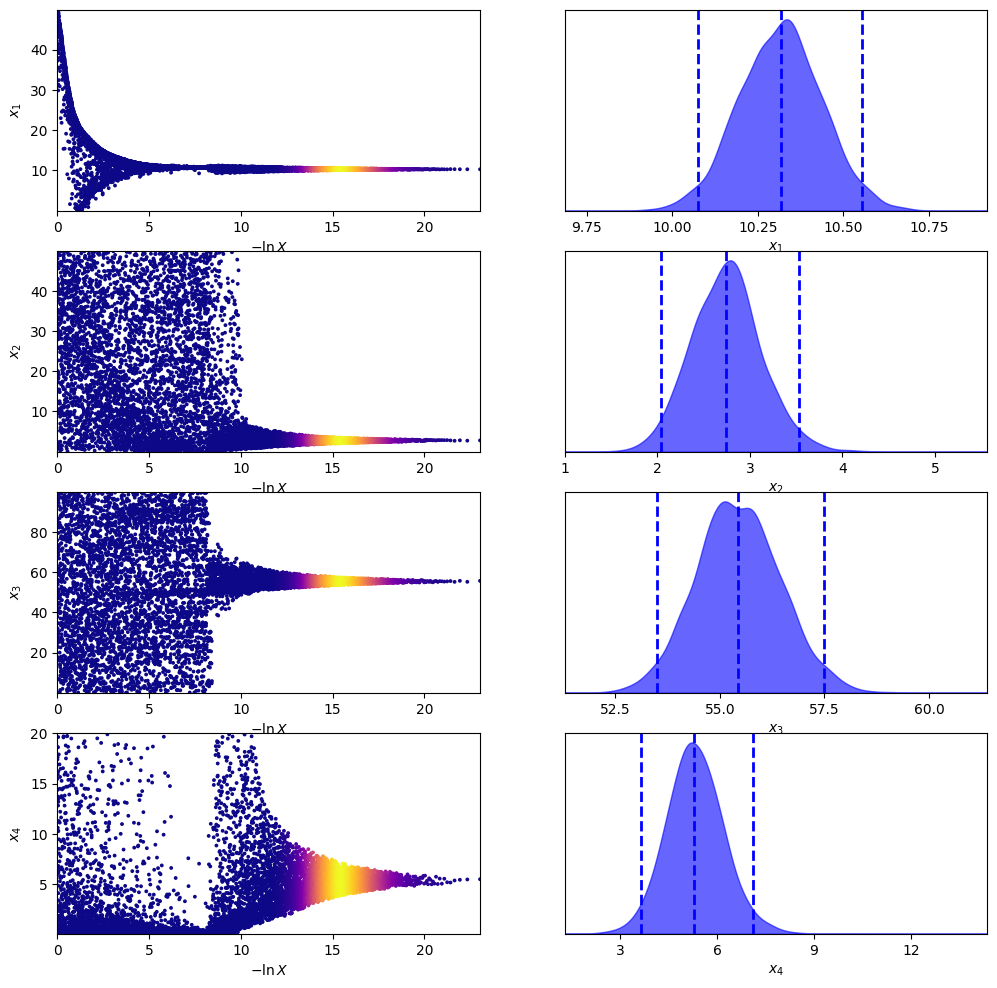

In [30]:
tfig, taxes = dyplot.traceplot(sresults2)

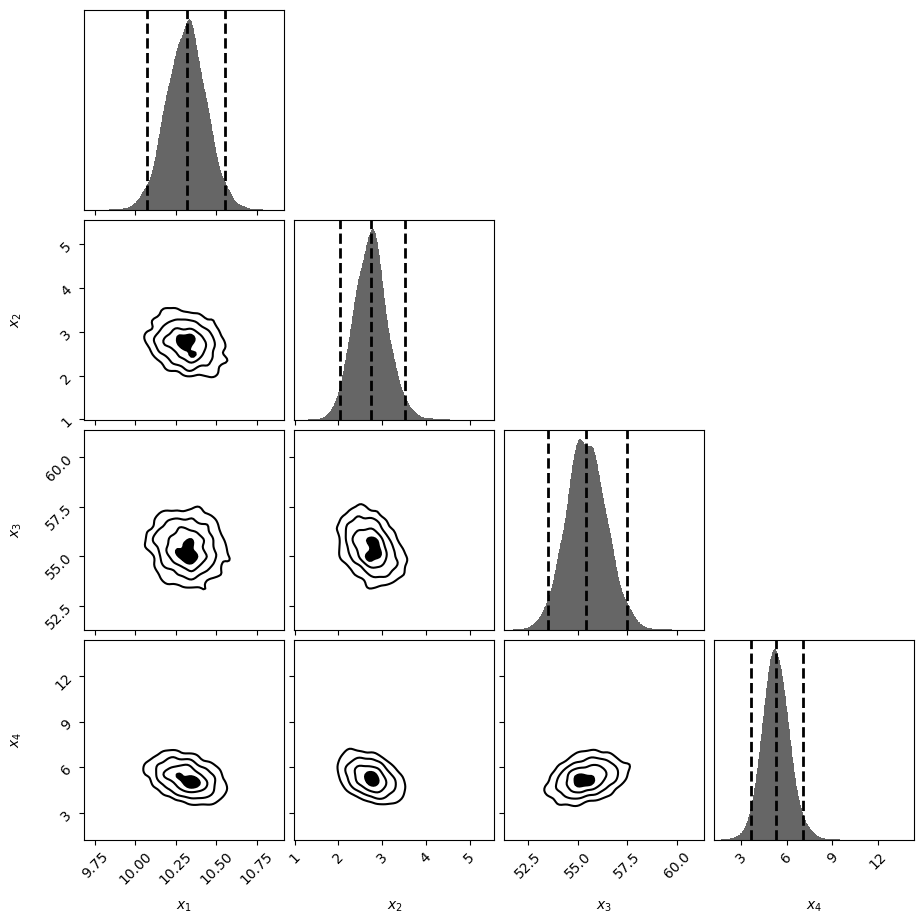

In [31]:
cfig, caxes = dyplot.cornerplot(sresults2)

In [32]:
# Extract sampling results.
samples2 = sresults2.samples  # samples
weights2 = np.exp(sresults2.logwt - sresults2.logz[-1])  # normalized weights


evidence2 = sresults2.logz[-1] #evidence
print("Bayesian evidence", np.exp(evidence2))

# Compute 10%-90% quantiles.
quantiles2 = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights2)
             for samps in samples2.T]
print('68% parameter credible regions are:\n ' + str(quantiles2) + '\n')

# Compute weighted mean and covariance.
mean2, cov2 = dyfunc.mean_and_cov(samples2, weights2)
print('Mean and covariance of parameters are: ' + str(mean2) + '\n' + str(cov2))

# Generate a new set of results with statistical+sampling uncertainties.
#results_sim = dyfunc.simulate_run(sresults)

Bayesian evidence 1.7102414321315635e-30
68% parameter credible regions are:
 [[10.193851823844994, 10.43460263238134], [2.373393289703226, 3.0911158505787846], [54.442460678952706, 56.44414899281637], [4.476256158940279, 6.14548339143246]]

Mean and covariance of parameters are: [10.31578159  2.7448292  55.43778642  5.3108856 ]
[[ 0.01447817 -0.00942004 -0.0160728  -0.03899669]
 [-0.00942004  0.14098114 -0.13423635 -0.13653417]
 [-0.0160728  -0.13423635  1.00778461  0.30114082]
 [-0.03899669 -0.13653417  0.30114082  0.76390018]]


In [33]:
quantiles2 = [dyfunc.quantile(samps, [0.05, 0.5, 0.95], weights=weights2)
             for samps in samples2.T]
for q,l in zip(quantiles2,['b', 'A', 't0', 'sigma']):
    low,med,up=q
    print(l+"   "+str(med)+" +"+str(up-med)+" -"+str(med-low))

b   10.318506789722283 +0.19416752472544374 -0.1992064774250597
A   2.7430575034886417 +0.6349878420436976 -0.6043259588617409
t0   55.42295229010734 +1.6862150817109267 -1.5889186665520043
sigma   5.281782598093303 +1.5143923264057353 -1.357822799133018


In [34]:

sresults2.summary()

Summary
nlive: 500
niter: 8416
ncall: 140002
eff(%):  6.368
logz: -68.541 +/-  0.309


In [35]:
# Resample weighted samples.
samples_equal2 = dyfunc.resample_equal(samples2, weights2)

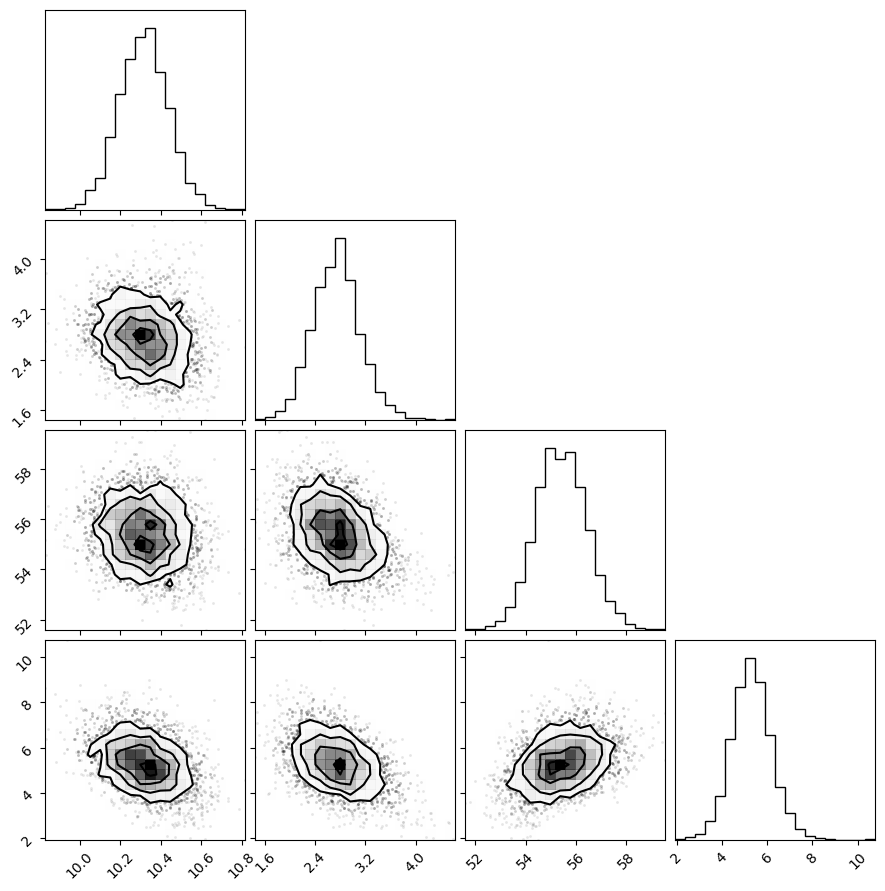

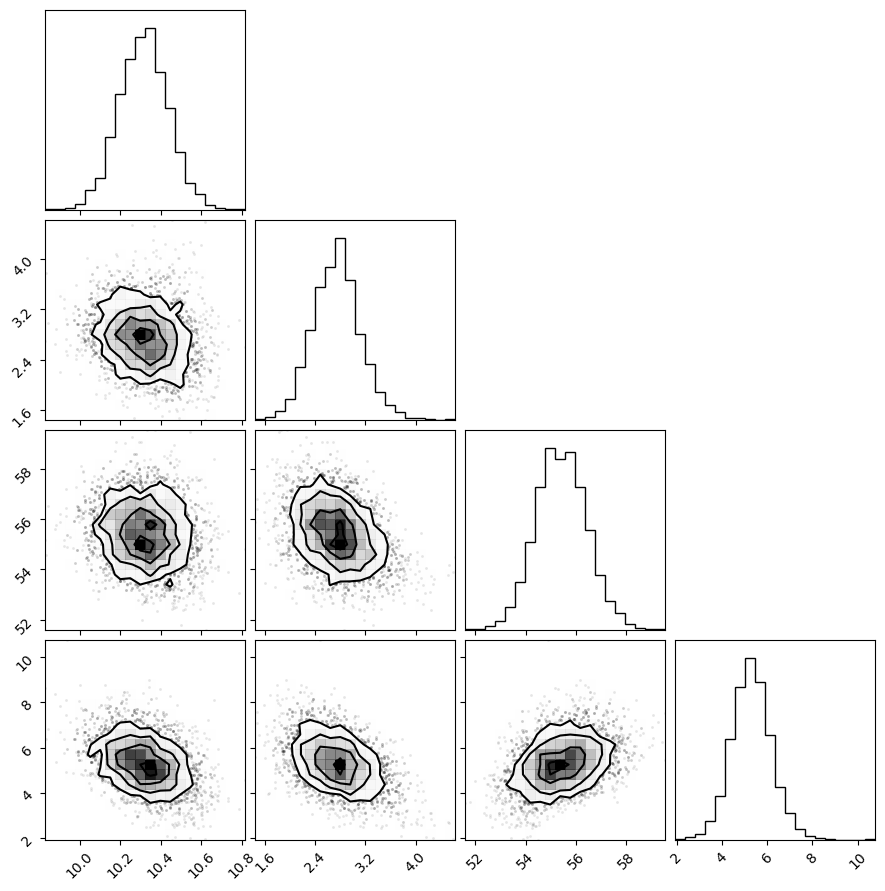

In [36]:
corner.corner(samples_equal2)

Text(0, 0.5, 'Flux')

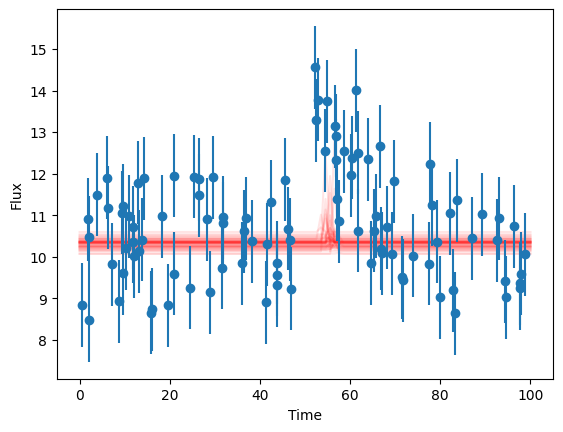

In [40]:
tgrid=np.linspace(0,100,100)

chosen_samples= samples_equal2[np.random.choice(len(samples_equal2),size=50)]

for chosen_params in chosen_samples:

    ygrid =  burst_model(chosen_params,tgrid)
    plt.plot(tgrid,ygrid,alpha=0.1,c='red')
    
plt.errorbar(t,y,yerr=y_err,fmt='o')
plt.xlabel("Time")
plt.ylabel("Flux")

Gaussian profile doesn't seem to fit very well.

### Odds ratio

Indeed odds ratio selects burst model

In [42]:
# adding errors
lnz1, lnz1err = sresults.logz[-1], sresults.logzerr[-1]
lnz2, lnz2err = sresults2.logz[-1], sresults2.logzerr[-1]

# Bayes factor
K = np.exp(lnz1 - lnz2)

# Error propagation
sigma_K = K * np.sqrt(lnz1err**2 + lnz2err**2)

print(f"Bayes Factor K: {K:.2f} ± {sigma_K:.2f}")

Bayes Factor K: 217.82 ± 93.28
